<a href="https://colab.research.google.com/github/RichaGaharwar/Advanced-Python-Web-Api-Scrapping./blob/main/Web_Api_%26_Scrapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
#WebAPI:

---
API stands for Application Programming Interface

---
API call:

---

* protocol -> HTTP
* Authentication
* Functional request
  * URL for the endpoint
  * Parameters
  * syntax
  * sample responses

In [3]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

JavaScript -> scrapy or selenium

No JavaScript -> BeautifulSoup


```
To check which language the website is using:

website -> inspect -> disable javascript -> reload

if the page is working that means javascript is not used
and we can scrape the data using BeautifulSoup

Else use scrapy or Selenium

```

---
Types of requests:

---

* GET
* POST
* PUT
* DELETE


```
We'll have a URL were we'll decide which type of request we want.
```



In [4]:
url = ''
url = "https://api.ipify.org"
response = requests.get(url)
response

<Response [200]>

---
Response status code:

---

* 1xx -> informational
* 2xx -> success
* 3xx -> redirected
* 4xx -> client error (not found)
* 5xx -> server code

In [5]:
response.status_code

200

In [8]:
response.text

'35.252.170.244'

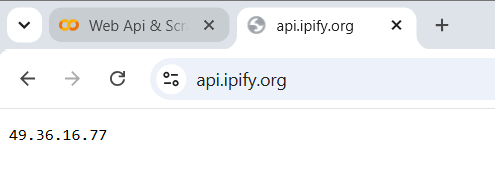

---
Different IP addresses.

---
why?

---
because we are using google colab notebook hence all the computations are happening on a system that google has provided to us (colab) therefore we get different IP adresses
since we are using google's resources so we get google's IP adress as output

#GitHub API

In [10]:
base_url = "https://api.github.com"

In [15]:
username = "RichaGaharwar "
url = base_url + 'users/'+ username
url

'https://api.github.comusers/RichaGaharwar '

In [19]:
username = "RichaGaharwar ".strip()
url = base_url + '/users/' + username
res = requests.get(url)

In [20]:
res.text

'{"login":"RichaGaharwar","id":124981714,"node_id":"U_kgDOB3MR0g","avatar_url":"https://avatars.githubusercontent.com/u/124981714?v=4","gravatar_id":"","url":"https://api.github.com/users/RichaGaharwar","html_url":"https://github.com/RichaGaharwar","followers_url":"https://api.github.com/users/RichaGaharwar/followers","following_url":"https://api.github.com/users/RichaGaharwar/following{/other_user}","gists_url":"https://api.github.com/users/RichaGaharwar/gists{/gist_id}","starred_url":"https://api.github.com/users/RichaGaharwar/starred{/owner}{/repo}","subscriptions_url":"https://api.github.com/users/RichaGaharwar/subscriptions","organizations_url":"https://api.github.com/users/RichaGaharwar/orgs","repos_url":"https://api.github.com/users/RichaGaharwar/repos","events_url":"https://api.github.com/users/RichaGaharwar/events{/privacy}","received_events_url":"https://api.github.com/users/RichaGaharwar/received_events","type":"User","user_view_type":"public","site_admin":false,"name":"Rich

JSON data

In [22]:
import json
output = json.loads(res.text)
output

{'login': 'RichaGaharwar',
 'id': 124981714,
 'node_id': 'U_kgDOB3MR0g',
 'avatar_url': 'https://avatars.githubusercontent.com/u/124981714?v=4',
 'gravatar_id': '',
 'url': 'https://api.github.com/users/RichaGaharwar',
 'html_url': 'https://github.com/RichaGaharwar',
 'followers_url': 'https://api.github.com/users/RichaGaharwar/followers',
 'following_url': 'https://api.github.com/users/RichaGaharwar/following{/other_user}',
 'gists_url': 'https://api.github.com/users/RichaGaharwar/gists{/gist_id}',
 'starred_url': 'https://api.github.com/users/RichaGaharwar/starred{/owner}{/repo}',
 'subscriptions_url': 'https://api.github.com/users/RichaGaharwar/subscriptions',
 'organizations_url': 'https://api.github.com/users/RichaGaharwar/orgs',
 'repos_url': 'https://api.github.com/users/RichaGaharwar/repos',
 'events_url': 'https://api.github.com/users/RichaGaharwar/events{/privacy}',
 'received_events_url': 'https://api.github.com/users/RichaGaharwar/received_events',
 'type': 'User',
 'user_v

#Save the image

In [23]:
output['avatar_url']

'https://avatars.githubusercontent.com/u/124981714?v=4'

save image

In [25]:
fp = open("{}.png".format(username), 'wb')
img_data = requests.get(output['avatar_url'])
fp.write(img_data.content)
fp.close

<function BufferedWriter.close()>

##Get details about logged in user

In [28]:
res = requests.get(base_url+"/user")
res

<Response [401]>

Since I haven't logged in I am getting error.

Authentication is required first.


#Scrapping

In [6]:
books_info = []

for x in range(1, 51):

  website = (f"https://books.toscrape.com/catalogue/page-{x}.html")
  r = requests.get(website)
  soup = BeautifulSoup(r.content, 'html.parser')
  book = soup.find_all("li", class_ = "col-xs-6 col-sm-4 col-md-3 col-lg-3")

  for item in book:
    name_tag = item.find("h3").find("a")
    book_name = name_tag.text.strip()
    book_link = name_tag["href"]
    price = item.find("p", class_ = "price_color").text.strip()

    all_products = {
        "Name" : book_name,
        "Link" : book_link,
        "Price" : price
    }

  books_info.append(all_products)

df = pd.DataFrame(books_info)
df.to_csv("Books_Info.csv", index = False)


In [7]:
books = pd.read_csv("Books_Info.csv")
books.head()

,Name,Link,Price
0,It's Only the Himalayas,its-only-the-himalayas_981/index.html,£45.17
1,You can't bury them ...,you-cant-bury-them-all-poems_961/index.html,£33.63
2,The Natural History of ...,the-natural-history-of-us-the-fine-art-of-pret...,£45.22
3,"Rat Queens, Vol. 3: ...",rat-queens-vol-3-demons-rat-queens-collected-e...,£50.40
4,In the Country We ...,in-the-country-we-love-my-family-divided_901/i...,£22.00
